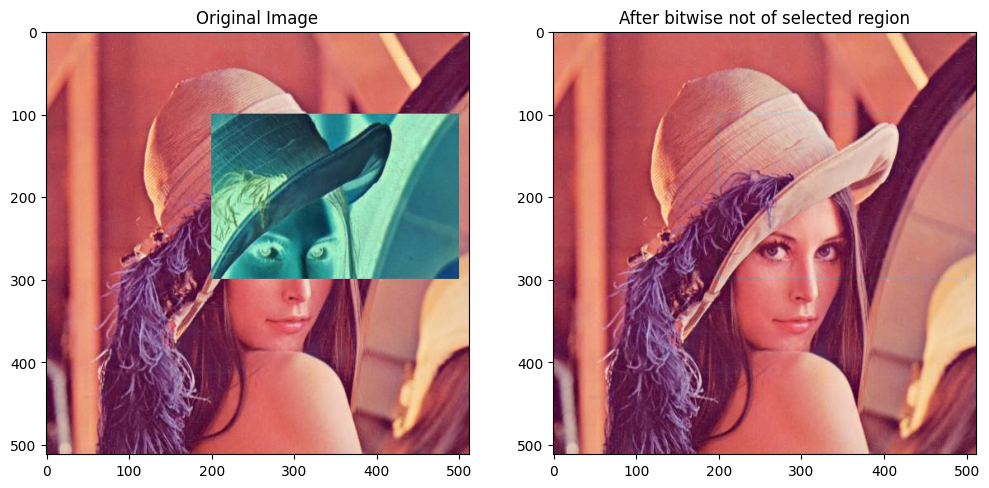

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

# Read the original image
img_original = cv.imread('images/result_regions.jpeg')

# Create a copy of original image
img = img_original.copy()

# Define the selected region position and size
x0, y0, w, h = 100, 200, 300, 200

# Extract the selected region
selected_region = img[x0:x0+h, y0:y0+w,:]

# Invert pixel values in the selected regio
selected_region_inv = cv.bitwise_not(selected_region)

# Replace the region with its inverted version
img[x0:x0+h, y0:y0+w,:] = selected_region_inv

# Display images
plt.figure(figsize=[12,6])
plt.subplot(121);plt.imshow(img_original[...,::-1]);plt.title("Original Image");
plt.subplot(122);plt.imshow(img[...,::-1]);plt.title("After bitwise not of selected region");
plt.show()


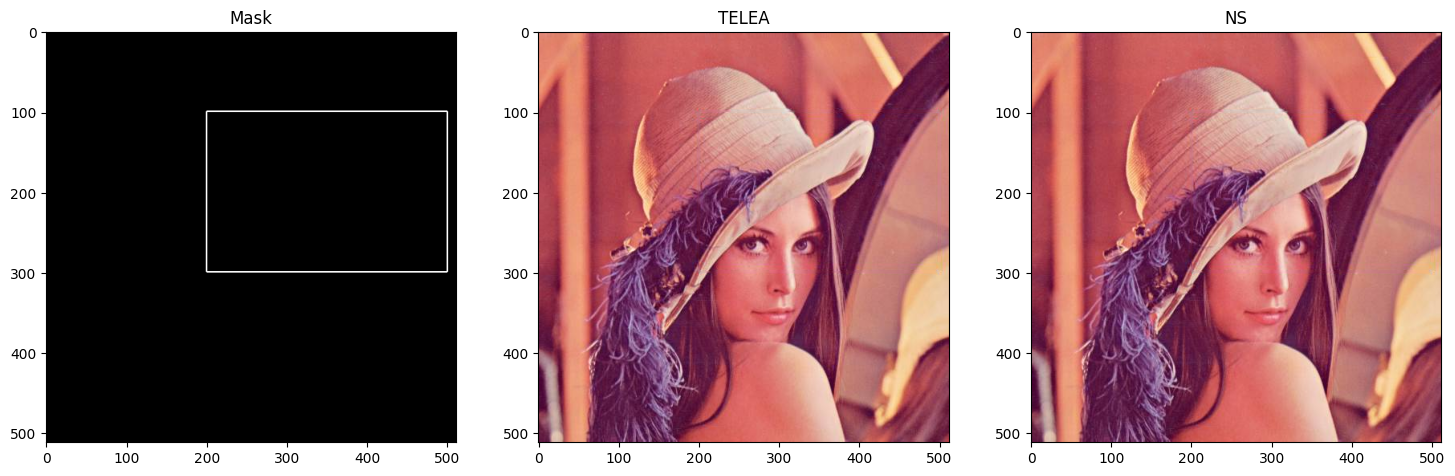

In [3]:
# Create an empty mask
mask = np.zeros(img.shape[:2], np.uint8)

# Mark the left border of the rectangle
mask[x0:x0+h, y0-1:y0+1] = 255
# Mark the right border of the rectangle
mask[x0:x0+h, y0+w-1:y0+w+1] = 255
# Mark the top border of the rectangle
mask[x0-1:x0+1, y0:y0+w] = 255
# Mark the bottom border of the rectangle
mask[x0+h-1:x0+h+1, y0:y0+w] = 255

# Remove the border using Telea method
telea = cv.inpaint(src=img, inpaintMask=mask, inpaintRadius=3, flags=cv.INPAINT_TELEA)
# Remove the border using Navier-Stokes method
ns = cv.inpaint(src=img, inpaintMask=mask, inpaintRadius=3, flags=cv.INPAINT_NS)

# Display images
plt.figure(figsize=[18,6])
plt.subplot(131);plt.imshow(mask, cmap='gray');plt.title("Mask");
plt.subplot(132);plt.imshow(telea[...,::-1]);plt.title("TELEA");
plt.subplot(133);plt.imshow(ns[...,::-1]);plt.title("NS");